In [ ]:
import yfinance as yf
# calls an API to download daily stocks and indies prices

In [ ]:
sp500= yf.Ticker("^GSPC")
# intialzing a ticker class which enables us to download price
# history in a single symbol(s and p 500 index)

In [ ]:
sp500=sp500.history(period="max")

In [ ]:
sp500

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,0.0,0.0
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-01 00:00:00-05:00,6812.299805,6843.649902,6799.939941,6812.629883,4549370000,0.0,0.0
2025-12-02 00:00:00-05:00,6830.959961,6851.549805,6806.709961,6829.370117,4582290000,0.0,0.0
2025-12-03 00:00:00-05:00,6815.290039,6862.419922,6810.430176,6849.720215,4736780000,0.0,0.0


In [ ]:
sp500.index
# hepls us to slice and initilise the dataframe easily

DatetimeIndex(['1927-12-30 00:00:00-05:00', '1928-01-03 00:00:00-05:00',
               '1928-01-04 00:00:00-05:00', '1928-01-05 00:00:00-05:00',
               '1928-01-06 00:00:00-05:00', '1928-01-09 00:00:00-05:00',
               '1928-01-10 00:00:00-05:00', '1928-01-11 00:00:00-05:00',
               '1928-01-12 00:00:00-05:00', '1928-01-13 00:00:00-05:00',
               ...
               '2025-11-21 00:00:00-05:00', '2025-11-24 00:00:00-05:00',
               '2025-11-25 00:00:00-05:00', '2025-11-26 00:00:00-05:00',
               '2025-11-28 00:00:00-05:00', '2025-12-01 00:00:00-05:00',
               '2025-12-02 00:00:00-05:00', '2025-12-03 00:00:00-05:00',
               '2025-12-04 00:00:00-05:00', '2025-12-05 00:00:00-05:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=24600, freq=None)

<Axes: xlabel='Date'>

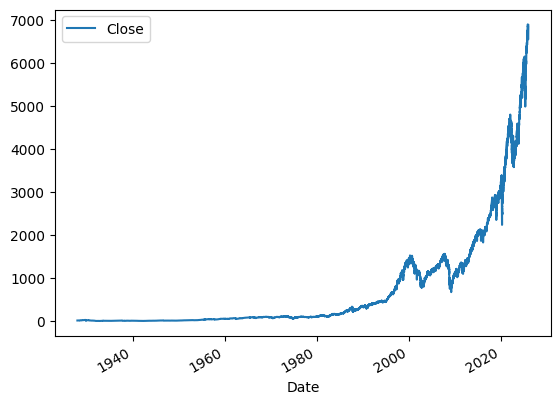

In [ ]:
sp500.plot.line(y="Close",use_index=True)

In [ ]:
sp500 = sp500.drop(columns=["Dividends", "Stock Splits"])

In [ ]:
sp500["tomorrow"]=sp500["Close"].shift(-1)

In [ ]:
sp500

,Open,High,Low,Close,Volume,tomorrow
Date,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.760000
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,17.719999
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,17.549999
1928-01-05 00:00:00-05:00,17.549999,17.549999,17.549999,17.549999,0,17.660000
1928-01-06 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,17.500000
...,...,...,...,...,...,...
2025-12-01 00:00:00-05:00,6812.299805,6843.649902,6799.939941,6812.629883,4549370000,6829.370117
2025-12-02 00:00:00-05:00,6830.959961,6851.549805,6806.709961,6829.370117,4582290000,6849.720215
2025-12-03 00:00:00-05:00,6815.290039,6862.419922,6810.430176,6849.720215,4736780000,6857.120117


In [ ]:
sp500["Target"]=(sp500["tomorrow"] > sp500["Close"]).astype(int)

In [ ]:
sp500=sp500.loc["1990-01-01":].copy()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=2,
    random_state=1
)

train=sp500.iloc[:-100]
test=sp500.iloc[-100:]
predictors=["Close","Volume","Open","High","Low"]
model.fit(train[predictors],train["Target"])


RandomForestClassifier(n_estimators=200, random_state=1)

In [ ]:
from sklearn.metrics import precision_score

In [ ]:
preds=model.predict(test[predictors])

In [ ]:
import pandas as pd
preds=pd.Series(preds,index=test.index)

In [ ]:
preds

,0
Date,
2025-07-17 00:00:00-04:00,0
2025-07-18 00:00:00-04:00,0
2025-07-21 00:00:00-04:00,0
2025-07-22 00:00:00-04:00,0
2025-07-23 00:00:00-04:00,0
...,...
2025-12-01 00:00:00-05:00,0
2025-12-02 00:00:00-05:00,0
2025-12-03 00:00:00-05:00,0


In [ ]:
precision_score(test["Target"],preds)

1.0

In [ ]:
combined=pd.concat([test["Target"],preds],axis=1)

<Axes: xlabel='Date'>

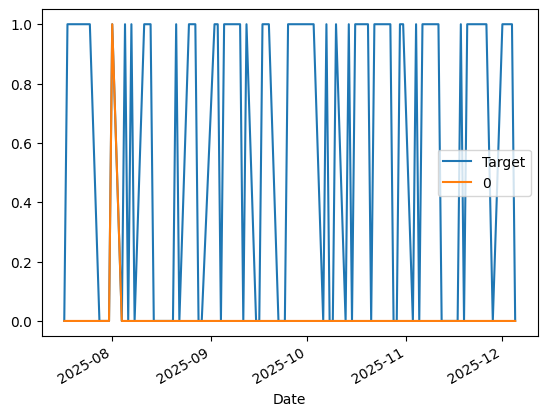

In [ ]:
combined.plot()

In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict(test[predictors])
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

def backtest(data, predictors, start=2500, step=250):
    all_predictions = []

    for i in range(start, data.shape[0], step):
        train = data.iloc[:i]
        test = data.iloc[i:i+step]

        model = RandomForestClassifier(
            n_estimators=100,
            min_samples_split=5,
            random_state=1
        )

        preds = predict(train, test, predictors, model)
        all_predictions.append(preds)

    return pd.concat(all_predictions)

predictions = backtest(sp500, predictors)


In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0,3984
1,2566


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5319563522992985

In [ ]:
predictions["Target"].value_counts() / predictions.shape[0]

,count
Target,
1,0.53771
0,0.46229


In [ ]:
horizon_list=[2,5,60,250,1000]
new_predictors=[]
for h in horizon_list:
    # Explicitly select numeric columns for rolling mean calculation
    rolling_averages=sp500[predictors].rolling(h).mean()
    trend_column=f"Trend_{h}"
    sp500[trend_column]=sp500.shift(1).rolling(h).sum()["Target"]
    new_predictors+=[ratio_column, trend_column]

In [ ]:
sp500


,Open,High,Low,Close,Volume,tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000,358.760010,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000,355.670013,0,0.998706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000,352.200012,0,0.995675,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000,353.790009,1,0.995098,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000,349.619995,0,1.002252,1.0,0.993731,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01 00:00:00-05:00,6812.299805,6843.649902,6799.939941,6812.629883,4549370000,6829.370117,1,0.997331,1.0,1.003471,4.0,1.016236,38.0,1.108472,142.0,1.372833,530.0
2025-12-02 00:00:00-05:00,6830.959961,6851.549805,6806.709961,6829.370117,4582290000,6849.720215,1,1.001227,1.0,1.002268,4.0,1.017887,38.0,1.110630,142.0,1.375612,530.0
2025-12-03 00:00:00-05:00,6815.290039,6862.419922,6810.430176,6849.720215,4736780000,6857.120117,1,1.001488,2.0,1.002787,4.0,1.020066,38.0,1.113360,142.0,1.379114,530.0


In [ ]:
sp500=sp500.dropna()

In [ ]:
sp500

,Open,High,Low,Close,Volume,tomorrow,Target,Close_Ratio_2,Trend_2,Close_Ratio_5,Trend_5,Close_Ratio_60,Trend_60,Close_Ratio_250,Trend_250,Close_Ratio_1000,Trend_1000
Date,,,,,,,,,,,,,,,,,
1993-12-14 00:00:00-05:00,465.730011,466.119995,462.459991,463.059998,275050000,461.839996,0,0.997157,1.0,0.996617,1.0,1.000283,32.0,1.028047,127.0,1.176082,512.0
1993-12-15 00:00:00-05:00,463.059998,463.690002,461.839996,461.839996,331770000,463.339996,1,0.998681,0.0,0.995899,1.0,0.997329,32.0,1.025151,126.0,1.172676,512.0
1993-12-16 00:00:00-05:00,461.859985,463.980011,461.859985,463.339996,284620000,466.380005,1,1.001621,1.0,0.999495,2.0,1.000311,32.0,1.028274,127.0,1.176163,513.0
1993-12-17 00:00:00-05:00,463.339996,466.380005,463.339996,466.380005,363750000,465.850006,0,1.003270,2.0,1.004991,3.0,1.006561,32.0,1.034781,128.0,1.183537,514.0
1993-12-20 00:00:00-05:00,466.380005,466.899994,465.529999,465.850006,255900000,465.299988,0,0.999431,1.0,1.003784,2.0,1.005120,32.0,1.033359,128.0,1.181856,513.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-28 00:00:00-05:00,6822.520020,6850.859863,6819.750000,6849.089844,2558540000,6812.629883,0,1.002670,2.0,1.015110,5.0,1.022516,38.0,1.114970,143.0,1.380798,531.0
2025-12-01 00:00:00-05:00,6812.299805,6843.649902,6799.939941,6812.629883,4549370000,6829.370117,1,0.997331,1.0,1.003471,4.0,1.016236,38.0,1.108472,142.0,1.372833,530.0
2025-12-02 00:00:00-05:00,6830.959961,6851.549805,6806.709961,6829.370117,4582290000,6849.720215,1,1.001227,1.0,1.002268,4.0,1.017887,38.0,1.110630,142.0,1.375612,530.0


In [ ]:
model=RandomForestClassifier(n_estimators=200, min_samples_split=50,random_state=1)

In [ ]:
def predict(train, test, predictors, model):
    model.fit(train[predictors], train["Target"])
    preds = model.predict_proba(test[predictors])[:,1]
    preds[preds>=.6]=1
    preds[preds<.6]=0
    preds = pd.Series(preds, index=test.index, name="Predictions")
    combined = pd.concat([test["Target"], preds], axis=1)
    return combined

In [ ]:
predictions=backtest(sp500, new_predictors)


In [ ]:
predictions["Predictions"].value_counts()

,count
Predictions,
0.0,4101
1.0,1448


In [ ]:
precision_score(predictions["Target"], predictions["Predictions"])

0.5573204419889503